In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from numpy.linalg import slogdet, inv
from sklearn.neighbors import kneighbors_graph
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")
import random
from matplotlib.colors import ListedColormap
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import norm
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.ndimage import convolve
import pickle

# [Zhou et al 2020] spatial aided GMM SAGMM

In [2]:
class SpatiallyAidedGMM:
    def __init__(self, n_clusters=2, n_spatial_components=2, max_iter=100):
        self.n_clusters = n_clusters
        self.n_spatial_components = n_spatial_components
        self.max_iter = max_iter
        self.gmm_feature = GaussianMixture(n_components=n_clusters, max_iter=max_iter)
        self.gmm_spatial = [GaussianMixture(n_components=n_spatial_components, max_iter=max_iter) for _ in range(n_clusters)]

    def fit(self, X, S):
        """
        X: Feature matrix (kinematic data) of shape (M, D)
        S: Spatial coordinates of shape (M, 2)
        """
        # Step 1: Fit GMM on kinematic features
        self.gmm_feature.fit(X)
        cluster_assignments = self.gmm_feature.predict(X)
        
        # Step 2: Fit spatial GMM for each cluster
        for k in range(self.n_clusters):
            cluster_indices = np.where(cluster_assignments == k)[0]
            if len(cluster_indices) > self.n_spatial_components:
                self.gmm_spatial[k].fit(S[cluster_indices])
            else:
                self.gmm_spatial[k] = None  # Avoid fitting on very few points
        
    def predict_proba(self, X, S):
        """
        Compute the probability of each point belonging to a cluster.
        """
        feature_probs = self.gmm_feature.predict_proba(X)
        spatial_probs = np.zeros_like(feature_probs)
        
        for k in range(self.n_clusters):
            if self.gmm_spatial[k] is not None:
                spatial_probs[:, k] = np.exp(self.gmm_spatial[k].score_samples(S))
        
        # Normalize spatial probabilities
        spatial_probs /= spatial_probs.sum(axis=1, keepdims=True) + 1e-10
        
        # Compute final probability as the product of feature and spatial probabilities
        final_probs = feature_probs * spatial_probs
        final_probs /= final_probs.sum(axis=1, keepdims=True) + 1e-10
        return final_probs
    
    def predict(self, X, S):
        """
        Assign each point to the most probable cluster.
        """
        return np.argmax(self.predict_proba(X, S), axis=1)



# [Zao et al 2016] Spatial GMM SGMM

In [3]:
def extract_sliding_windows(image, window_size=3):
    pad = window_size // 2
    padded_image = np.pad(image, pad, mode='edge')
    windows = []
    centers = []
    for i in range(pad, pad + image.shape[0]):
        for j in range(pad, pad + image.shape[1]):
            window = padded_image[i-pad:i+pad+1, j-pad:j+pad+1].flatten()
            windows.append(window)
            centers.append((i-pad, j-pad))
    return np.array(windows), centers
def sgmm(image, K=3, window_size=3, max_iter=10, tol=1e-4,random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    windows, centers = extract_sliding_windows(image, window_size)
    M, N = windows.shape
    D = 1  # grayscale


    flat_pixels = image.reshape(-1, 1)
    kmeans = KMeans(n_clusters=K, n_init=10, random_state=random_state).fit(flat_pixels)
    
    # Initial mean µ_k from kmeans centers
    mu = kmeans.cluster_centers_.flatten()
    
    
    sigma2 = np.zeros((K, 1))
    #labels = kmeans.labels_.reshape(image.shape)
    for k in range(K):
        pixels_in_k = flat_pixels[kmeans.labels_ == k]
        sigma2[k, 0] = np.var(pixels_in_k) + 1e-4 
    alpha = np.ones((M, K)) / K
    rng = np.random.RandomState(random_state)
    tau = rng.dirichlet(np.ones(K), (M, N))
    L_prev = None
    grad_L = 1
    t = 0
    
    while grad_L > tol and t < max_iter:
        # --- M-step ---
        for k in range(K):
            numerator = np.sum(tau[:, :, k] * windows)
            denominator = np.sum(tau[:, :, k])
            mu[k] = numerator / (denominator + 1e-12)

            sigma2[k, 0] = np.sum(tau[:, :, k] * (windows - mu[k])**2) / (denominator + 1e-12)

        alpha = np.sum(tau, axis=1) / N

        # --- E-step ---
        pdfs = np.zeros((M, N, K))
        for k in range(K):
            pdfs[:, :, k] = norm.pdf(windows, mu[k], np.sqrt(sigma2[k, 0]))
        weighted_pdfs = alpha[:, np.newaxis, :] * pdfs
        denominator = np.sum(weighted_pdfs, axis=2, keepdims=True) + 1e-12
        tau = weighted_pdfs / denominator

        # --- Log-likelihood ---
        L_new = 0
        L_new = np.sum(np.log(np.sum(weighted_pdfs, axis=2) + 1e-12)) / N
    

        # --- Verbosity ---
        if L_prev is not None:
            grad_L = np.abs(L_prev - L_new) / (np.abs(L_prev) + 1e-12)
        else:
            grad_L = np.inf

        # print(f"Iter {t:02d} | LogL = {L_new:.5f} | ∇L = {grad_L:.5e}",end="/")
        # print(f"   μ: {mu}")
        # print(f"   σ²: {sigma2.flatten()}")

        L_prev = L_new
        label_image = np.zeros_like(image, dtype=int)
        labels = np.argmax(alpha, axis=1)
        for idx, (i, j) in enumerate(centers):
            label_image[i, j] = labels[idx]
        # plt.imshow(label_image,cmap='gray')
        # plt.show()
        t += 1

    return label_image, mu, sigma2,alpha

# [Wang 2012, GMM+HMRF]

In [4]:
def gmm_hmrf_from_gmm(
    X,
    gmm,
    image_shape,
    beta=1.0,
    n_gmm_components=1,
    max_em_iter=10,
    max_icm_iter=5,
    tol=1e-3,
    random_state=0,
):
    """
    GMM-HMRF segmentation using a pre-fitted GMM.

    Parameters
    ----------
    X : np.ndarray (N, d)
    gmm : GaussianMixture
        Pre-fitted global GMM
    image_shape : (H, W)
    beta : float
    n_gmm_components : int
    """

    rng = np.random.RandomState(random_state)

    H, W = image_shape
    n_labels = gmm.n_components
    d = X.shape[1]

    # --- Initialization from GMM
    labels = gmm.predict(X).reshape(H, W)

    pixels = X.copy()

    # --- Initialize one GMM per label
    gmms = []
    for c in range(n_labels):
        Xc = pixels[labels.ravel() == c]

        if len(Xc) < max(n_gmm_components, 2):
            Xc = pixels[rng.choice(len(pixels), size=20, replace=True)]

        gmm_c = GaussianMixture(
            n_components=n_gmm_components,
            covariance_type="full",
            random_state=random_state,
            reg_covar=1e-6,
        )
        gmm_c.fit(Xc)
        gmms.append(gmm_c)

    energy_history = []
    prev_energy = None

    def neighbors_cost(labels, c):
        up = np.zeros_like(labels, dtype=bool)
        up[1:, :] = labels[:-1, :] != c

        down = np.zeros_like(labels, dtype=bool)
        down[:-1, :] = labels[1:, :] != c

        left = np.zeros_like(labels, dtype=bool)
        left[:, 1:] = labels[:, :-1] != c

        right = np.zeros_like(labels, dtype=bool)
        right[:, :-1] = labels[:, 1:] != c

        return (
            up.astype(float)
            + down.astype(float)
            + left.astype(float)
            + right.astype(float)
        )

    for em_it in range(max_em_iter):

        # --- E step (unary)
        unary = np.zeros((n_labels, H, W))
        for c in range(n_labels):
            ll = gmms[c].score_samples(pixels)
            unary[c] = (-ll).reshape(H, W)

        # --- ICM
        for _ in range(max_icm_iter):
            local_energy = np.zeros((n_labels, H, W))

            for c in range(n_labels):
                local_energy[c] = unary[c] + beta * neighbors_cost(labels, c)

            new_labels = np.argmin(local_energy, axis=0)
            if np.all(new_labels == labels):
                break
            labels = new_labels

        # --- M step
        for c in range(n_labels):
            Xc = pixels[labels.ravel() == c]

            if len(Xc) < max(n_gmm_components, 2):
                Xc = pixels[rng.choice(len(pixels), size=20, replace=True)]

            gmms[c] = GaussianMixture(
                n_components=n_gmm_components,
                covariance_type="full",
                random_state=random_state,
                reg_covar=1e-6,
            )
            gmms[c].fit(Xc)

        # --- Energy
        energy = 0.0
        for c in range(n_labels):
            mask = labels == c
            energy += unary[c][mask].sum()

        energy += beta * np.sum(labels[1:, :] != labels[:-1, :])
        energy += beta * np.sum(labels[:, 1:] != labels[:, :-1])

        energy_history.append(float(energy))

        if prev_energy is not None:
            rel = abs(prev_energy - energy) / max(abs(prev_energy), 1e-12)
            if rel < tol:
                break

        prev_energy = energy

    return labels, energy_history

# GMM+CRF

In [5]:
def gmm_crf_from_gmm(
    X,
    gmm,
    image_shape,
    beta=1.0,
    max_iter=10,
    tol=1e-3,
):
    """
    GMM-CRF segmentation using a pre-fitted GMM.

    Parameters
    ----------
    X : np.ndarray, shape (N, d)
        Feature matrix.
    gmm : GaussianMixture
        Pre-fitted GMM model.
    image_shape : tuple (H, W)
        Shape of the image.
    beta : float
        Pairwise smoothness weight.
    max_iter : int
        Number of ICM iterations.
    tol : float
        Convergence tolerance.

    Returns
    -------
    labels : np.ndarray, shape (H, W)
    energy_history : list
    """

    H, W = image_shape
    n_labels = gmm.n_components

    # Unary: -log p(x | label)
    log_prob = gmm._estimate_weighted_log_prob(X)  # (N, K)
    unary = -log_prob.reshape(H, W, n_labels).transpose(2, 0, 1)

    # Init
    labels = np.argmin(unary, axis=0)

    energy_history = []
    prev_energy = None

    def pairwise_cost(labels, c):
        up = np.zeros_like(labels, dtype=bool)
        up[1:, :] = labels[:-1, :] != c

        down = np.zeros_like(labels, dtype=bool)
        down[:-1, :] = labels[1:, :] != c

        left = np.zeros_like(labels, dtype=bool)
        left[:, 1:] = labels[:, :-1] != c

        right = np.zeros_like(labels, dtype=bool)
        right[:, :-1] = labels[:, 1:] != c

        return (
            up.astype(float)
            + down.astype(float)
            + left.astype(float)
            + right.astype(float)
        )

    for it in range(max_iter):
        local_energy = np.zeros((n_labels, H, W))

        for c in range(n_labels):
            local_energy[c] = unary[c] + beta * pairwise_cost(labels, c)

        new_labels = np.argmin(local_energy, axis=0)
        labels = new_labels

        # Energy
        energy = 0.0
        for c in range(n_labels):
            mask = labels == c
            energy += unary[c][mask].sum()

        energy += beta * np.sum(labels[1:, :] != labels[:-1, :])
        energy += beta * np.sum(labels[:, 1:] != labels[:, :-1])

        energy_history.append(float(energy))

        if prev_energy is not None:
            rel = abs(prev_energy - energy) / max(abs(prev_energy), 1e-12)
            if rel < tol:
                break

        prev_energy = energy

    return labels, energy_history

# GMM-LAP

In [34]:
import numpy as np
from numpy.linalg import slogdet, inv
from sklearn.cluster import KMeans
from sklearn.neighbors import kneighbors_graph


def _logsumexp(values, axis=None, keepdims=False):
    """
    Compute log-sum-exp in a numerically stable way.
    """
    max_values = np.max(values, axis=axis, keepdims=True)
    output = max_values + np.log(np.sum(np.exp(values - max_values), axis=axis, keepdims=True))

    if not keepdims:
        output = np.squeeze(output, axis=axis)

    return output


def _row_normalize(matrix, eps=1e-12):
    """
    Normalize rows so that each row sums to 1.
    """
    row_sums = matrix.sum(axis=1, keepdims=True)
    row_sums = np.maximum(row_sums, eps)
    return matrix / row_sums


class LaplacianRegularizedGMM:
    """
    Laplacian-Regularized Gaussian Mixture Model.

    The algorithm alternates between:
    1. A standard GMM E-step to compute responsibilities
    2. Graph-based smoothing of responsibilities
    3. A standard GMM M-step using the smoothed responsibilities

    Parameters
    ----------
    n_components : int, default=3
        Number of Gaussian components.
    n_neighbors : int, default=10
        Number of neighbors used to build the k-NN graph.
    smoothing : float, default=0.3
        Strength of graph-based responsibility smoothing.
    smoothing_steps : int, default=10
        Number of smoothing iterations per EM step.
    max_iter : int, default=100
        Maximum number of EM iterations.
    tol : float, default=1e-4
        Convergence tolerance on the proxy objective.
    reg_covar : float, default=1e-6
        Diagonal covariance regularization.
    random_state : int or None, default=None
        Random seed.
    verbose : bool, default=False
        If True, prints optimization progress.
    """

    def __init__(
        self,
        n_components=3,
        n_neighbors=10,
        smoothing=0.3,
        smoothing_steps=10,
        max_iter=100,
        tol=1e-4,
        reg_covar=1e-6,
        random_state=None,
        verbose=False,
    ):
        self.n_components = n_components
        self.n_neighbors = n_neighbors
        self.smoothing = smoothing
        self.smoothing_steps = smoothing_steps
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.random_state = random_state
        self.verbose = verbose

        self.weights_ = None
        self.means_ = None
        self.covariances_ = None
        self.resp_ = None
        self.labels_ = None
        self.objective_history_ = []

    def _build_graph(self, X):
        """
        Build a symmetric k-NN connectivity graph.
        """
        adjacency = kneighbors_graph(
            X,
            n_neighbors=self.n_neighbors,
            mode="connectivity",
            include_self=False,
        )
        similarity = adjacency.maximum(adjacency.T).astype(float)
        return similarity.toarray()

    def _initialize_parameters(self, X):
        """
        Initialize mixture parameters with KMeans.
        """
        n_samples, n_features = X.shape

        kmeans = KMeans(
            n_clusters=self.n_components,
            n_init=10,
            random_state=self.random_state,
        )
        initial_labels = kmeans.fit_predict(X)

        rng = np.random.default_rng(self.random_state)

        self.means_ = np.zeros((self.n_components, n_features))
        self.covariances_ = np.zeros((self.n_components, n_features, n_features))
        self.weights_ = np.zeros(self.n_components)

        for component_id in range(self.n_components):
            X_component = X[initial_labels == component_id]

            if len(X_component) == 0:
                self.means_[component_id] = X[rng.integers(0, n_samples)]
                self.covariances_[component_id] = np.eye(n_features)
                self.weights_[component_id] = 1.0 / self.n_components
                continue

            self.means_[component_id] = X_component.mean(axis=0)

            if len(X_component) > 1:
                covariance = np.cov(X_component.T)
            else:
                covariance = np.eye(n_features)

            covariance = np.atleast_2d(covariance)
            covariance += self.reg_covar * np.eye(n_features)

            self.covariances_[component_id] = covariance
            self.weights_[component_id] = len(X_component) / n_samples

        self.weights_ /= self.weights_.sum()

    def _estimate_log_gaussian_prob(self, X):
        """
        Compute log Gaussian densities for all samples and components.

        Returns
        -------
        np.ndarray of shape (n_samples, n_components)
        """
        n_samples, n_features = X.shape
        log_prob = np.zeros((n_samples, self.n_components))

        for component_id in range(self.n_components):
            mean = self.means_[component_id]
            covariance = self.covariances_[component_id] + self.reg_covar * np.eye(n_features)

            sign, logdet = slogdet(covariance)
            if sign <= 0:
                covariance = covariance + 1e-3 * np.eye(n_features)
                sign, logdet = slogdet(covariance)

            precision = inv(covariance)
            diff = X - mean
            mahalanobis = np.sum((diff @ precision) * diff, axis=1)

            log_prob[:, component_id] = -0.5 * (
                n_features * np.log(2.0 * np.pi) + logdet + mahalanobis
            )

        return log_prob

    def _e_step(self, X):
        """
        Standard GMM E-step.

        Returns
        -------
        responsibilities : np.ndarray of shape (n_samples, n_components)
        log_likelihood : float
        """
        weighted_log_prob = self._estimate_log_gaussian_prob(X) + np.log(
            np.maximum(self.weights_, 1e-12)
        )
        log_prob_norm = _logsumexp(weighted_log_prob, axis=1)
        log_responsibilities = weighted_log_prob - log_prob_norm[:, None]
        responsibilities = np.exp(log_responsibilities)

        return responsibilities, log_prob_norm.sum()

    def _smooth_responsibilities(self, responsibilities, similarity):
        """
        Smooth responsibilities over the graph.

        Each smoothing step computes a weighted neighbor average and blends it
        with the current responsibilities.
        """
        degree = similarity.sum(axis=1, keepdims=True)
        degree = np.maximum(degree, 1e-12)

        smoothed = responsibilities.copy()

        for _ in range(self.smoothing_steps):
            neighbor_average = (similarity @ smoothed) / degree
            smoothed = (1.0 - self.smoothing) * smoothed + self.smoothing * neighbor_average
            smoothed = _row_normalize(np.clip(smoothed, 1e-12, None))

        return smoothed

    def _m_step(self, X, responsibilities):
        """
        Standard GMM M-step using the provided responsibilities.
        """
        n_samples, n_features = X.shape
        effective_counts = responsibilities.sum(axis=0) + 1e-12

        self.weights_ = effective_counts / n_samples
        self.means_ = (responsibilities.T @ X) / effective_counts[:, None]

        self.covariances_ = np.zeros((self.n_components, n_features, n_features))

        for component_id in range(self.n_components):
            diff = X - self.means_[component_id]
            weighted_diff = responsibilities[:, component_id][:, None] * diff
            covariance = (weighted_diff.T @ diff) / effective_counts[component_id]
            covariance += self.reg_covar * np.eye(n_features)
            self.covariances_[component_id] = covariance

    def _regularization_value(self, responsibilities, similarity):
        """
        Compute the graph regularization term:
            1/2 * sum_{i,j} S_ij (f_i - f_j)^2
        summed over all components.
        """
        regularization = 0.0

        for component_id in range(self.n_components):
            f_k = responsibilities[:, component_id]
            diff = f_k[:, None] - f_k[None, :]
            regularization += 0.5 * np.sum(similarity * (diff ** 2))

        return regularization

    def fit(self, X):
        """
        Fit the Laplacian-Regularized GMM.
        """
        X = np.asarray(X, dtype=float)
        n_samples, _ = X.shape

        if self.n_components < 1:
            raise ValueError("n_components must be at least 1.")
        if self.n_components > n_samples:
            raise ValueError("n_components cannot exceed the number of samples.")

        self._initialize_parameters(X)
        similarity = self._build_graph(X)

        previous_objective = -np.inf
        self.objective_history_ = []

        for iteration in range(self.max_iter):
            responsibilities, _ = self._e_step(X)
            smoothed_responsibilities = self._smooth_responsibilities(responsibilities, similarity)
            self._m_step(X, smoothed_responsibilities)

            _, log_likelihood_after = self._e_step(X)
            regularization = self._regularization_value(smoothed_responsibilities, similarity)

            objective = log_likelihood_after - self.smoothing * regularization
            self.objective_history_.append(objective)

            if self.verbose:
                print(
                    f"Iteration {iteration + 1:03d} | "
                    f"loglik={log_likelihood_after:.6f} | "
                    f"reg={regularization:.6f} | "
                    f"obj={objective:.6f}"
                )

            if abs(objective - previous_objective) < self.tol:
                if self.verbose:
                    print("Convergence reached.")
                break

            previous_objective = objective
            self.resp_ = smoothed_responsibilities

        self.labels_ = np.argmax(self.resp_, axis=1)
        return self

    def predict_proba(self, X):
        """
        Predict posterior probabilities from the fitted GMM parameters.

        Note
        ----
        This method returns the standard GMM posterior probabilities and does
        not apply graph smoothing to unseen data.
        """
        X = np.asarray(X, dtype=float)
        responsibilities, _ = self._e_step(X)
        return responsibilities

    def predict(self, X):
        """
        Predict labels from posterior probabilities.
        """
        return np.argmax(self.predict_proba(X), axis=1)

    def fit_predict(self, X):
        """
        Fit the model and return training labels.
        """
        self.fit(X)
        return self.labels_

# KB-SGMM

In [10]:
def gaussian_kernel(size, sigma=1.0):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    return kernel / np.sum(kernel)


def kb_sgmm(dataset, gmm_model, lambda_=0.0, window_size=7):
    h, w = dataset.shape
    X_val = dataset.reshape(-1, 1)
    
    # GMM shape probabilities (h * w, n_classes)
    probs = gmm_model.predict_proba(X_val)
    probs_2d = probs.reshape(h, w, -1)

    # kernel = np.ones((window_size, window_size), dtype=np.float32) / (window_size ** 2)
    kernel = gaussian_kernel(window_size, sigma=window_size / 6)
    
    smoothed = np.stack([
        convolve(probs_2d[:, :, i], kernel, mode='reflect')
        for i in range(probs_2d.shape[-1])
    ], axis=-1)

    corrected = lambda_ * probs_2d + (1 - lambda_) * smoothed

    # corrected /= corrected.sum(axis=-1, keepdims=True)

    return np.argmax(corrected, axis=-1),corrected,probs_2d

In [11]:
def evaluate_clustering(true_labels, pred_labels):
    true_labels, pred_labels = true_labels.flatten(),pred_labels.flatten()
    return {
        "ARI": round(adjusted_rand_score(true_labels, pred_labels),3),
        "NMI": round(normalized_mutual_info_score(true_labels, pred_labels),3)
    }



In [12]:
def plot_clustering_results_list(d_name,results_list, h, w, methods=None, cmap='tab10'):
    """
    Plot clustering results from multiple datasets in a grid (1 row per dataset).

    Parameters:
    - results_list: list of dicts, each with keys as method names and values as label arrays
    - h, w: height and width to reshape the label arrays into images
    - methods: list of methods to include (optional)
    - cmap: colormap to use
    """

    n_datasets = len(results_list)

    # Determine all methods if not provided
    if methods is None:
        methods = list(results_list[0].keys())

    n_methods = len(methods)
    fig, axes = plt.subplots(nrows=n_datasets, ncols=n_methods, figsize=(4 * n_methods, 4 * n_datasets))

    # Ensure axes is 2D even if there's only one row or one column
    if n_datasets == 1:
        axes = np.expand_dims(axes, 0)
    if n_methods == 1:
        axes = np.expand_dims(axes, 1)

    for row_idx, results in enumerate(results_list):
        for col_idx, method in enumerate(methods):
            ax = axes[row_idx, col_idx]
            img = results[method].reshape(h, w)
            im = ax.imshow(img, cmap=cmap, vmin=0, vmax=np.max(img))
            ax.set_title(d_name+f"{row_idx+1} - {method}")
            ax.axis('off')

    plt.tight_layout()
    plt.savefig('clustering_'+d_name+'.png',dpi=300,bbox_inches='tight')
    plt.show()

In [13]:
def correct_clustering_labels(true_labels, predicted_labels):
    true_labels = np.asarray(true_labels)
    predicted_labels = np.asarray(predicted_labels)

    cm = confusion_matrix(true_labels, predicted_labels)

    # Hungarian algorithm to maximize correct label matching
    row_ind, col_ind = linear_sum_assignment(-cm)

    label_mapping = {col: row for row, col in zip(row_ind, col_ind)}
    
    corrected_labels = np.array([label_mapping[label] for label in predicted_labels])

    return corrected_labels



In [26]:
def run_clustering_pipeline(X, S, true_labels, n_clusters=3,
                            window_size=6, lambda_=0.3,
                            sgmm_max_iter=40, sgmm_tol=1e-6,
                            random_state=0):
    results = {}
    probas = {}
    h = w = int(np.sqrt(len(X)))
    dataset_reshaped = X.reshape(h, w)
    results['True_labels'] = true_labels.flatten()
    # --- KMEANS ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state).fit(X)
    results["KMeans"] = correct_clustering_labels(true_labels.flatten(),kmeans.labels_)

    # --- GMM classique ---
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=random_state,tol=1e-5).fit(X)
    results["GMM"] =  correct_clustering_labels(true_labels.flatten(),gmm.predict(X))
    

    # --- Spatially Aided GMM ---
    sagmm = SpatiallyAidedGMM(n_clusters=n_clusters)
    sagmm.fit(X, S)
    results["SAGMM"] =  correct_clustering_labels(true_labels.flatten(),sagmm.predict(X, S))
    # --- GMM-CRF ---
    labels_crf, energy_crf = gmm_crf_from_gmm(
        X=X,
        gmm=gmm,
        image_shape=(h, w),
        beta=1.0,
        max_iter=10,
    )

    results["GMM-CRF"] = correct_clustering_labels(
    true_labels.flatten(),
    labels_crf.flatten()
    )

    # --- GMM-HMRF ---
    labels_hmrf, energy_hmrf = gmm_hmrf_from_gmm(
        X=X,
        gmm=gmm,
        image_shape=(h, w),
        beta=1.0,
        max_em_iter=10,
    )
    
    results["GMM-HMRF"] = correct_clustering_labels(
        true_labels.flatten(),
        labels_hmrf.flatten()
    )

    # --- GMM-LAP ---
    model = LaplacianRegularizedGMM(
        n_components=n_clusters,
        n_neighbors=15,
        smoothing=0.4,
        smoothing_steps=15,
        max_iter=50,
        tol=1e-4,
        reg_covar=1e-4,
        random_state=42,
        verbose=random_state,
    )
    
    labels_gmm_lap = model.fit_predict(X)
    results["GMM_LAP"] = correct_clustering_labels(true_labels.flatten(),labels_gmm_lap.flatten()) 
    

    # --- SGMM ---
    labels_sgmm, mu_sgmm, sigma2_sgmm, probs_sgmm = sgmm(
        image=dataset_reshaped,
        K=n_clusters,
        window_size=window_size,
        max_iter=sgmm_max_iter,
        tol=sgmm_tol,
        random_state=random_state
    )
    results["SGMM"] =  correct_clustering_labels(true_labels.flatten(),labels_sgmm.flatten())
    # results["SGMM"] =  labels_sgmm.flatten()
    probas["SGMM"] = probs_sgmm

    
    # --- KB-SGMM (spatial smoothing) ---
    
    labels_kb, prob_kb, prob_gmm = kb_sgmm(dataset_reshaped, gmm, lambda_=lambda_, window_size=window_size)
    results["KB-SGMM"] =  correct_clustering_labels(true_labels.flatten(),labels_kb.flatten())
    # results["KB-SGMM"] =  labels_kb.flatten()
    probas["KB-SGMM"] = prob_kb.reshape(-1, n_clusters)
    probas["GMM"] = prob_gmm.reshape(-1, n_clusters)
   

    # --- Evaluation ---
    scores = {method: evaluate_clustering(true_labels, pred) for method, pred in results.items()}

    return results, scores, probas



In [27]:
X_indices = np.array([(i, j) for i in range(100) for j in range(100)])


In [28]:

# --- Load datasets ---
with open("simple_datasets.pkl", "rb") as file:
    datasets = pickle.load(file)

In [29]:
# Exemple avec sd1
sd1 = datasets['SD1']['data']
label_sd1 = datasets['SD1']['labels']
X1 = sd1.reshape(-1, 1)
S1 = X_indices.reshape(-1, 2)  # coordonnées spatiales (si disponibles)
results1, scores1,proba1, = run_clustering_pipeline(X1, S1, label_sd1, n_clusters=5, window_size=7, lambda_=0.)

# Exemple avec sd2
sd2 = datasets['SD2']['data']
label_sd2 = datasets['SD2']['labels']
X2 = sd2.reshape(-1, 1)
results2, scores2, proba2 = run_clustering_pipeline(X2, S1, label_sd2, n_clusters=5,window_size=7, lambda_=0.)

In [30]:
scores1

{'True_labels': {'ARI': 1.0, 'NMI': 1.0},
 'KMeans': {'ARI': 0.528, 'NMI': 0.605},
 'GMM': {'ARI': 0.524, 'NMI': 0.604},
 'SAGMM': {'ARI': 0.714, 'NMI': 0.751},
 'GMM-CRF': {'ARI': 0.84, 'NMI': 0.852},
 'GMM-HMRF': {'ARI': 0.912, 'NMI': 0.899},
 'GMM_LAP': {'ARI': 0.529, 'NMI': 0.606},
 'SGMM': {'ARI': 0.973, 'NMI': 0.961},
 'KB-SGMM': {'ARI': 0.949, 'NMI': 0.941}}

In [31]:
scores2

{'True_labels': {'ARI': 1.0, 'NMI': 1.0},
 'KMeans': {'ARI': 0.534, 'NMI': 0.603},
 'GMM': {'ARI': 0.546, 'NMI': 0.61},
 'SAGMM': {'ARI': 0.722, 'NMI': 0.752},
 'GMM-CRF': {'ARI': 0.859, 'NMI': 0.867},
 'GMM-HMRF': {'ARI': 0.904, 'NMI': 0.884},
 'GMM_LAP': {'ARI': 0.553, 'NMI': 0.611},
 'SGMM': {'ARI': 0.81, 'NMI': 0.856},
 'KB-SGMM': {'ARI': 0.939, 'NMI': 0.932}}

In [32]:
# --- Load datasets ---
with open("geological_synthetic_datasets.pkl", "rb") as file:
    gsd = pickle.load(file)

In [33]:
X_gsd1 = gsd["GSD1"]["data"].reshape(-1, 1)
X_gsd2 = gsd["GSD2"]["data"].reshape(-1, 1)
X_gsd3 = gsd["GSD3"]["data"].reshape(-1, 1)
X_gsd4 = gsd["GSD4"]["data"].reshape(-1, 1)

labels_gsd1 = gsd["GSD1"]["labels"]
labels_gsd2 = gsd["GSD2"]["labels"]
labels_gsd3 = gsd["GSD3"]["labels"]
labels_gsd4 = gsd["GSD4"]["labels"]

gds_1, score_gds1, proba_gds1 = run_clustering_pipeline(
    X_gsd1, S1, labels_gsd1, n_clusters=5, window_size=7, lambda_=0.0
)



In [35]:
score_gds1

{'True_labels': {'ARI': 1.0, 'NMI': 1.0},
 'KMeans': {'ARI': 0.518, 'NMI': 0.594},
 'GMM': {'ARI': 0.521, 'NMI': 0.597},
 'SAGMM': {'ARI': 0.691, 'NMI': 0.737},
 'GMM-CRF': {'ARI': 0.834, 'NMI': 0.85},
 'GMM-HMRF': {'ARI': 0.9, 'NMI': 0.886},
 'GMM_LAP': {'ARI': 0.521, 'NMI': 0.599},
 'SGMM': {'ARI': 0.805, 'NMI': 0.84},
 'KB-SGMM': {'ARI': 0.936, 'NMI': 0.93}}

In [36]:
gds_2, score_gds2, proba_gds2 = run_clustering_pipeline(
    X_gsd2, S1, labels_gsd2, n_clusters=5, window_size=7, lambda_=0.0
)


In [37]:
score_gds2

{'True_labels': {'ARI': 1.0, 'NMI': 1.0},
 'KMeans': {'ARI': 0.495, 'NMI': 0.602},
 'GMM': {'ARI': 0.504, 'NMI': 0.606},
 'SAGMM': {'ARI': 0.633, 'NMI': 0.723},
 'GMM-CRF': {'ARI': 0.748, 'NMI': 0.815},
 'GMM-HMRF': {'ARI': 0.869, 'NMI': 0.868},
 'GMM_LAP': {'ARI': 0.511, 'NMI': 0.606},
 'SGMM': {'ARI': 0.945, 'NMI': 0.925},
 'KB-SGMM': {'ARI': 0.886, 'NMI': 0.896}}

In [38]:
gds_3, score_gds3, proba_gds3 = run_clustering_pipeline(
    X_gsd3, S1, labels_gsd3, n_clusters=5, window_size=7, lambda_=0.0
)

In [39]:
score_gds30.

{'True_labels': {'ARI': 1.0, 'NMI': 1.0},
 'KMeans': {'ARI': 0.431, 'NMI': 0.564},
 'GMM': {'ARI': 0.475, 'NMI': 0.585},
 'SAGMM': {'ARI': 0.474, 'NMI': 0.608},
 'GMM-CRF': {'ARI': 0.682, 'NMI': 0.749},
 'GMM-HMRF': {'ARI': 0.745, 'NMI': 0.768},
 'GMM_LAP': {'ARI': 0.48, 'NMI': 0.587},
 'SGMM': {'ARI': 0.739, 'NMI': 0.766},
 'KB-SGMM': {'ARI': 0.797, 'NMI': 0.816}}

In [40]:
gds_4, score_gds4, proba_gds4 = run_clustering_pipeline(
    X_gsd4, S1, labels_gsd4, n_clusters=5, window_size=7, lambda_=0.0,sgmm_max_iter=100,sgmm_tol=1e-9
)

In [41]:
score_gds4

{'True_labels': {'ARI': 1.0, 'NMI': 1.0},
 'KMeans': {'ARI': 0.446, 'NMI': 0.556},
 'GMM': {'ARI': 0.465, 'NMI': 0.568},
 'SAGMM': {'ARI': 0.53, 'NMI': 0.628},
 'GMM-CRF': {'ARI': 0.722, 'NMI': 0.774},
 'GMM-HMRF': {'ARI': 0.694, 'NMI': 0.748},
 'GMM_LAP': {'ARI': 0.467, 'NMI': 0.568},
 'SGMM': {'ARI': 0.87, 'NMI': 0.828},
 'KB-SGMM': {'ARI': 0.818, 'NMI': 0.835}}

In [42]:
all_experiments = {
    "SD1": {
        "results": results1,
        "scores": scores1,
        "probas": proba1,
    },
    "SD2": {
        "results": results2,
        "scores": scores2,
        "probas": proba2,
    },
    "GSD1": {
        "results": gds_1,
        "scores": score_gds1,
        "probas": proba_gds1,
    },
    "GSD2": {
        "results": gds_2,
        "scores": score_gds2,
        "probas": proba_gds2,
    },
    "GSD3": {
        "results": gds_3,
        "scores": score_gds3,
        "probas": proba_gds3,
    },
    "GSD4": {
        "results": gds_4,
        "scores": score_gds4,
        "probas": proba_gds4,
    },
}

In [43]:
with open("clustering_results_4K.pkl", "wb") as f:
    pickle.dump(all_experiments, f)

In [49]:
gsd_list = [
    gds_1,
    gds_2,
    gds_3,
    gds_4
]
sd_list = [results1,results2]

In [45]:
COLORS = ["blue", "green", "red", "orange", "purple"]
CLUSTER_CMAP = ListedColormap(COLORS)

In [46]:
def plot_clustering_results_list(d_name, results_list, h, w, methods=None, cmap='tab10'):
    """
    Publication-ready clustering plot with improved spacing and font sizes.

    Parameters:
    - d_name: dataset name prefix
    - results_list: list of dicts {method_name: labels}
    - h, w: reshape dimensions
    - methods: optional list of methods
    - cmap: matplotlib colormap
    """

    n_datasets = len(results_list)

    if methods is None:
        methods = list(results_list[0].keys())

    n_methods = len(methods)

    fig, axes = plt.subplots(
        nrows=n_datasets,
        ncols=n_methods,
        figsize=(4 * n_methods, 4 * n_datasets)
    )

    # Ensure axes is 2D
    if n_datasets == 1:
        axes = np.expand_dims(axes, 0)
    if n_methods == 1:
        axes = np.expand_dims(axes, 1)

    for row_idx, results in enumerate(results_list):
        for col_idx, method in enumerate(methods):
            ax = axes[row_idx, col_idx]

            img = results[method].reshape(h, w)
            ax.imshow(img, cmap=cmap, vmin=0, vmax=np.max(img))

            # Column titles (only first row)
            if row_idx == 0:
                ax.set_title(method, fontsize=14, pad=12)

            # Row labels (only first column)
            if col_idx == 0:
                ax.set_ylabel(f"{d_name}{row_idx+1}", fontsize=14, labelpad=15)

            ax.set_xticks([])
            ax.set_yticks([])

    # Adjust spacing between subplots
    plt.subplots_adjust(
        hspace=0.05,
        wspace=0.05
    )

    plt.savefig(
        f'clustering_{d_name}.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

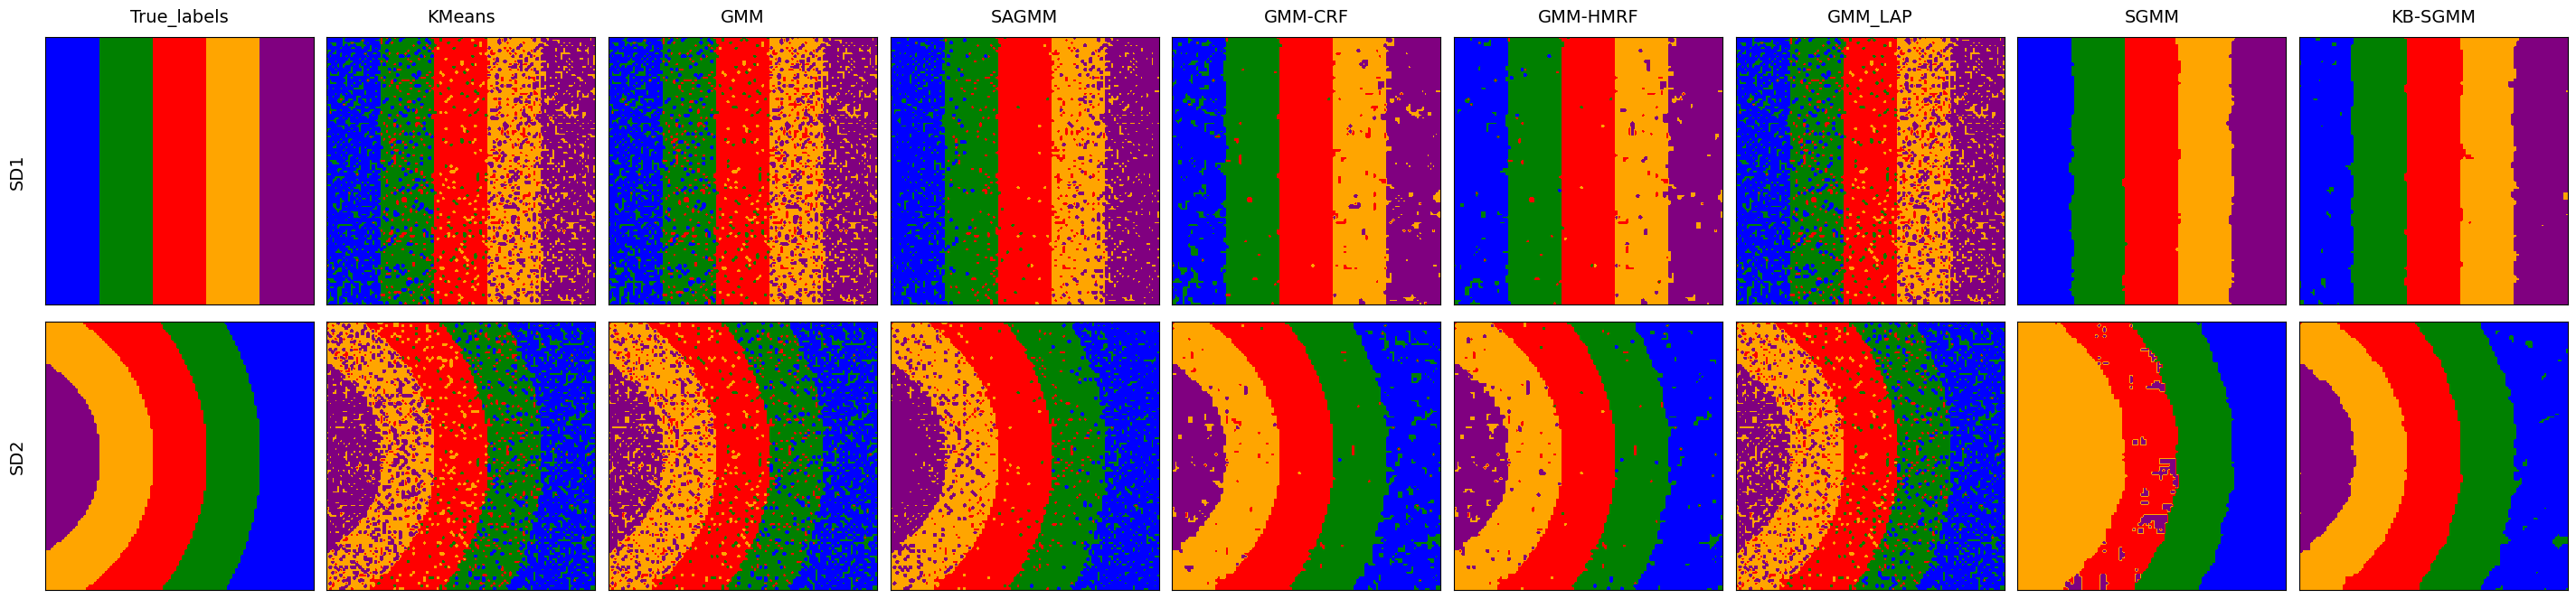

In [47]:
plot_clustering_results_list(
    d_name="SD",
    results_list=sd_list,
    h=100,
    w=100,
    cmap=CLUSTER_CMAP
)

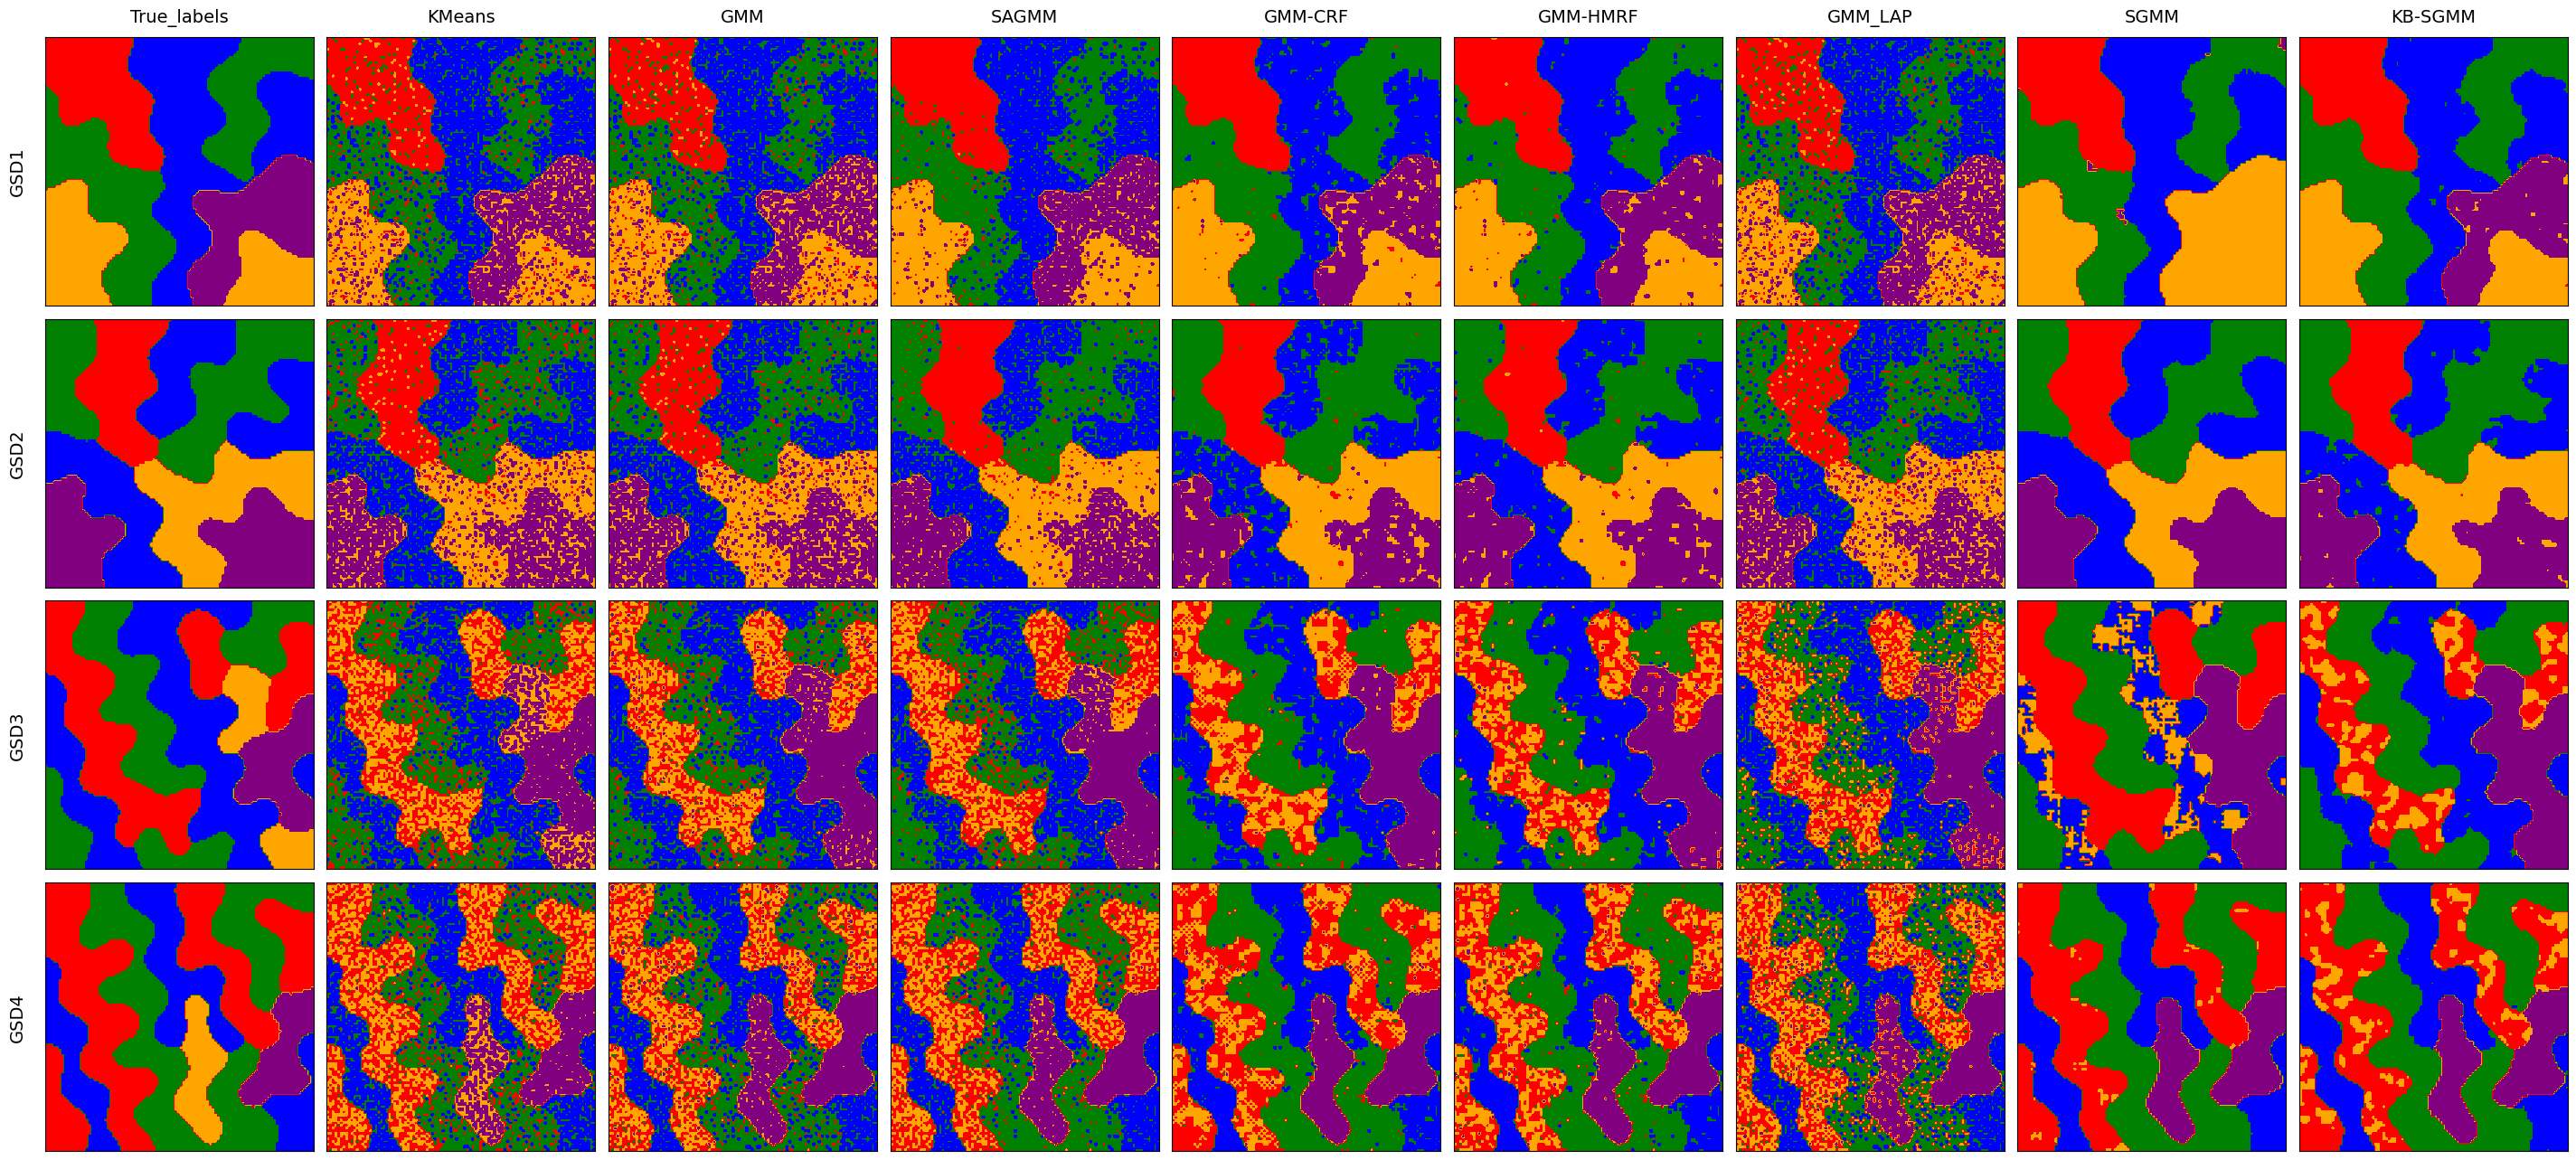

In [51]:
plot_clustering_results_list(
    d_name="GSD",
    results_list=gsd_list,
    h=100,
    w=100,
    cmap=CLUSTER_CMAP
)